In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb
import xgboost as xgb
import time
import re
print("All imports done")

All imports done


In [9]:
df_sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
df_train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
df_test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
print("Train Shape",df_train.shape)
print("Test Shape",df_test.shape)

Train Shape (198000, 15)
Test Shape (102000, 14)


In [10]:
df_train.sample(5)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
28452,2023-04-05 10:25:51.639256+00:00,39,0,0,0,1,0,6,10,white,none,none,False,Tell me about jbvqi it! Crime has gone way up ...,1
21173,2022-11-21 09:21:17.599945+00:00,39,0,0,0,3,0,0,6,NaN,NaN,NaN,False,Wrong Irresponsible to even suggest such a thi...,0
132495,2023-02-23 12:09:22.055823+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"In the meantime, Senator Murkowski has introdu...",2
75323,2024-03-23 23:27:21.336656+00:00,72,0,0,1,5,2,0,5,NaN,NaN,NaN,False,These are not asylum seekers. These are illeg...,0
28257,2023-07-31 09:11:37.990291+00:00,72,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"I believe that it was MoonHowler who dragged ""...",0


In [15]:
print(df_train.iloc[1,:])

created_date                     2024-03-24 21:43:11.490017+00:00
post_id                                                        39
emoticon_1                                                      0
emoticon_2                                                      0
emoticon_3                                                      0
upvote                                                          6
downvote                                                        0
if_1                                                            0
if_2                                                            4
race                                                          NaN
religion                                                      NaN
gender                                                        NaN
disability                                                  False
comment         Under Alaska law, a non-tribal member is not b...
label                                                           0
Name: 1, d

Milstone1-EDA

In [6]:
print("\nData Types:\n", df_train.dtypes)
print("\nMissing Values:\n", df_train.isnull().sum())
print("\nStatistical Summary:\n", df_train.describe())

print("\nLabel Distribution:")
for label in sorted(df_train['label'].unique()):
    count = (df_train['label'] == label).sum()
    pct   = count / len(df_train) * 100
    print(f"  Label {label}: {count:6d} ({pct:.1f}%)")

print(f"\nMedian upvotes              : {df_train['upvote'].median()}")
print(f"Min value of if_2           : {df_train['if_2'].min()}")

temp = df_train.copy()
temp['created_date_dt'] = pd.to_datetime(temp['created_date'], utc=True)
most_freq_month = temp['created_date_dt'].dt.month_name().str.lower().value_counts().idxmax()
print(f"Most frequent month         : {most_freq_month}")

temp['total_emoticons'] = temp['emoticon_1'] + temp['emoticon_2'] + temp['emoticon_3']
print(f"Max total_emoticons         : {temp['total_emoticons'].max()}")

label3_len = temp[temp['label'] == 3]['comment'].fillna('').apply(len)
print(f"Median comment len (label3) : {label3_len.median()}")

upvote_min = temp['upvote'].min()
upvote_max = temp['upvote'].max()
scaled_10  = (10 - upvote_min) / (upvote_max - upvote_min)
print(f"Min-Max scaled (upvote=10)  : {scaled_10:.4f}")

label1_wc = temp[temp['label'] == 1]['comment'].fillna('').apply(lambda x: len(x.split()))
print(f"Avg word count label 1      : {label1_wc.mean():.2f}")

trump_count = temp['comment'].fillna('').str.contains('trump', case=False).sum()
print(f"Comments with Trump         : {trump_count}")

del temp
print("\nEDA stats done df_train unchanged")


Data Types:
 created_date    object
post_id          int64
emoticon_1       int64
emoticon_2       int64
emoticon_3       int64
upvote           int64
downvote         int64
if_1             int64
if_2             int64
race            object
religion        object
gender          object
disability        bool
comment         object
label            int64
dtype: object

Missing Values:
 created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Statistical Summary:
              post_id     emoticon_1     emoticon_2     emoticon_3  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean       68.447429       0.279768       0.048338       0.121071   
std        27.948390 

EDA Plot

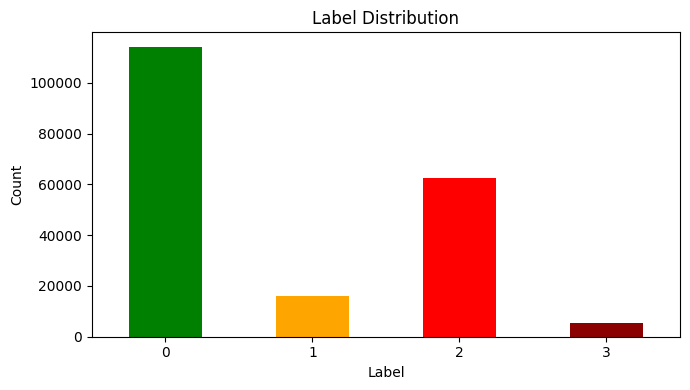

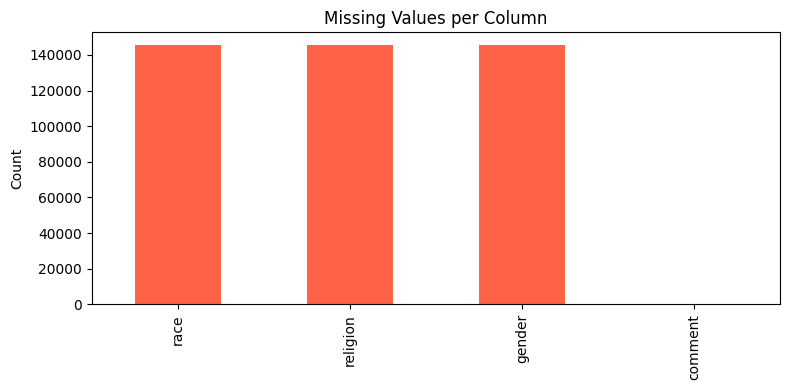

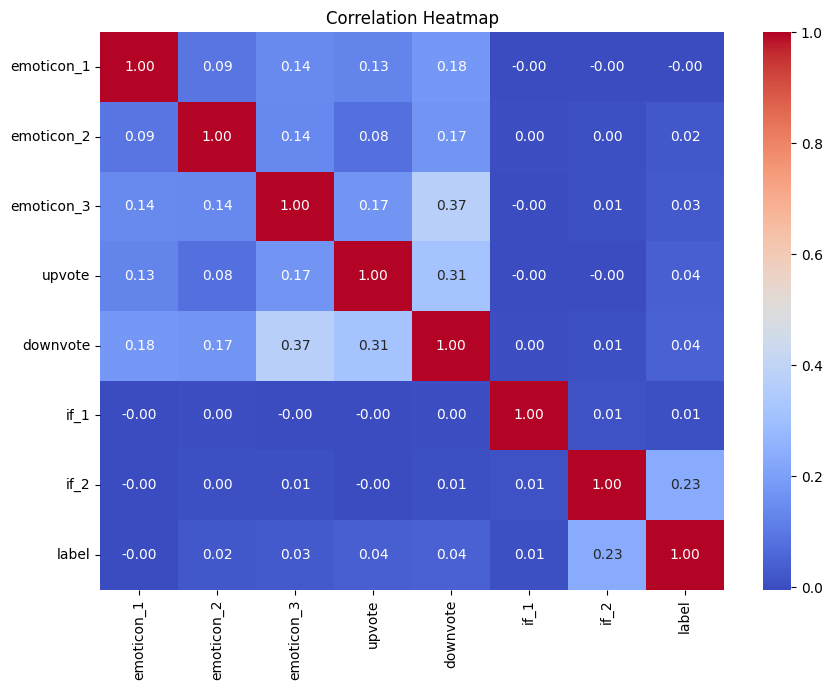

<Figure size 700x500 with 0 Axes>

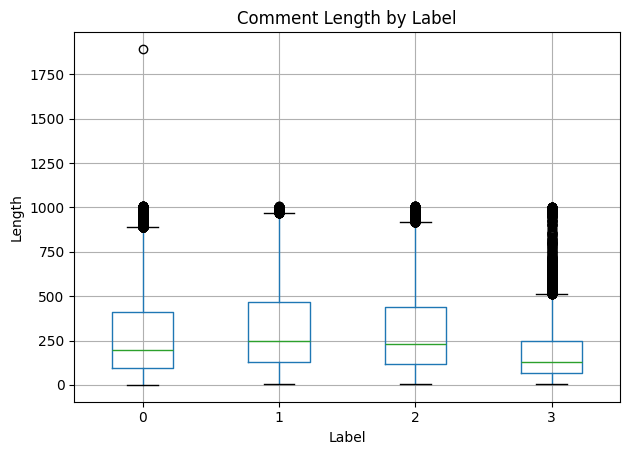

In [7]:
# 1.Lable Distribution
plt.figure(figsize=(7, 4))
df_train['label'].value_counts().sort_index().plot(
    kind='bar', color=['green', 'orange', 'red', 'darkred'])
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Missing values
plt.figure(figsize=(8, 4))
missing = df_train.isnull().sum()
missing = missing[missing > 0]
missing.plot(kind='bar', color='tomato')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# 3. Correlation heatmap
num_cols_eda = ['emoticon_1', 'emoticon_2', 'emoticon_3',
                'upvote', 'downvote', 'if_1', 'if_2', 'label']
plt.figure(figsize=(9, 7))
sns.heatmap(df_train[num_cols_eda].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# 4. Comment length by label 
temp2 = df_train.copy()
temp2['comment_length'] = temp2['comment'].fillna('').apply(len)
plt.figure(figsize=(7, 5))
temp2.boxplot(column='comment_length', by='label')
plt.title('Comment Length by Label')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Length')
plt.tight_layout()
plt.show()
del temp2

Preprocessing****

In [8]:
# STEP 1 — Load fresh data Again

df_train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
df_test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
print(f"Train : {df_train.shape}")
print(f"Test  : {df_test.shape}")


# STEP 2 — Basic cleaning

for dataset in [df_train, df_test]:
    # Missing values
    dataset['comment']    = dataset['comment'].fillna('')
    dataset['disability'] = dataset['disability'].astype(int)
    for col in ['race', 'religion', 'gender']:
        dataset[col] = dataset[col].fillna('unknown')

    # Datetime features
    dataset['created_date'] = pd.to_datetime(dataset['created_date'], utc=True)
    dataset['hour']         = dataset['created_date'].dt.hour
    dataset['month']        = dataset['created_date'].dt.month
    dataset['day_of_week']  = dataset['created_date'].dt.dayofweek
    dataset['is_weekend']   = (dataset['day_of_week'] >= 5).astype(int)
    dataset['is_night']     = ((dataset['hour'] >= 22) | 
                               (dataset['hour'] <= 5)).astype(int)
    dataset.drop(columns=['created_date'], inplace=True)

    # Numerical features
    dataset['total_votes']      = dataset['upvote'] + dataset['downvote']
    dataset['vote_ratio']       = dataset['upvote'] / (dataset['total_votes'] + 1)
    dataset['vote_diff']        = dataset['upvote'] - dataset['downvote']
    dataset['is_controversial'] = ((dataset['upvote'] > 0) & 
                                   (dataset['downvote'] > 0)).astype(int)
    dataset['total_emoticons']  = (dataset['emoticon_1'] + 
                                   dataset['emoticon_2'] + 
                                   dataset['emoticon_3'])
    dataset['has_emoticon']     = (dataset['total_emoticons'] > 0).astype(int)
    dataset['if_combined']      = dataset['if_1'] + dataset['if_2']

    # Text features
    dataset['comment_length']   = dataset['comment'].apply(len)
    dataset['word_count']       = dataset['comment'].apply(
                                  lambda x: len(str(x).split()))
    dataset['exclaim_count']    = dataset['comment'].apply(
                                  lambda x: str(x).count('!'))
    dataset['question_count']   = dataset['comment'].apply(
                                  lambda x: str(x).count('?'))
    dataset['caps_ratio']       = dataset['comment'].apply(
                                  lambda x: sum(1 for c in str(x) 
                                  if c.isupper()) / (len(str(x)) + 1))
    dataset['avg_word_length']  = dataset['comment'].apply(
                                  lambda x: np.mean([len(w) for w in 
                                  str(x).split()]) if str(x).split() else 0)

    # Clean text
    def clean_text(text):
        if pd.isna(text) or text == '': return 'empty'
        text = str(text).lower()
        text = re.sub(r'\n|\r', ' ', text)
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'[^a-zA-Z0-9\s!?.,]', '', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    dataset['comment_clean'] = dataset['comment'].apply(clean_text)

print("Basic cleaning done")
print(f"df_train : {df_train.shape}")

Train : (198000, 15)
Test  : (102000, 14)
Basic cleaning done
df_train : (198000, 33)


In [9]:
df_train.sample(5)

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,...,total_emoticons,has_emoticon,if_combined,comment_length,word_count,exclaim_count,question_count,caps_ratio,avg_word_length,comment_clean
35933,39,0,0,0,0,0,5,4,none,none,...,0,0,9,188,34,0,0,0.021164,4.558824,"from what the yibgs original article reported,..."
9059,39,0,0,0,13,2,0,10,unknown,unknown,...,0,0,10,600,111,0,1,0.021631,4.414414,i tuned to the comments because i just knew th...
185191,31,0,0,0,0,0,0,10,unknown,unknown,...,0,0,10,815,141,0,0,0.025735,4.787234,should paul ryan with or without trump go ahea...
237,72,0,0,0,22,1,0,4,unknown,unknown,...,0,0,4,45,9,0,0,0.086957,4.111111,"what has jt done, i cant think of anything.."
183604,72,0,0,0,22,0,0,10,unknown,unknown,...,0,0,10,54,9,0,0,0.018182,5.111111,they dont stand corrected they stand caught ly...


In [10]:
# STEP 3 — Extract target 

y      = df_train['label'].copy()
X_full = df_train.drop(columns=['label', 'post_id'])
df_test = df_test.drop(columns=['post_id'])

# Column groups
text_col = 'comment_clean'
cat_cols  = ['race', 'religion', 'gender']
num_cols  = [
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'if_1', 'if_2',
    'disability', 'hour', 'month', 'day_of_week',
    'is_weekend', 'is_night', 'total_votes',
    'vote_ratio', 'vote_diff', 'is_controversial',
    'total_emoticons', 'has_emoticon', 'if_combined',
    'comment_length', 'word_count', 'exclaim_count',
    'question_count', 'caps_ratio', 'avg_word_length'
]

# STEP 4 — SPLIT FIRST

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_full, y, test_size=0.2,
    random_state=42, stratify=y
)
print(f"X_train_raw : {X_train_raw.shape}")
print(f"X_val_raw   : {X_val_raw.shape}")

X_train_raw : (158400, 31)
X_val_raw   : (39600, 31)


In [11]:
# STEP 5 — Fit preprocessors on train data

# TF-IDF
tfidf        = TfidfVectorizer(
                   max_features=5000,#top 5000 word
                   ngram_range=(1, 2),
                   min_df=5, #word atleast in 5 row
                   max_df=0.90,#word maximum in 90 precent row
                   sublinear_tf=True #tf = 1+log(tf)
               )
X_train_text = tfidf.fit_transform(X_train_raw[text_col])
X_val_text   = tfidf.transform(X_val_raw[text_col])
X_test_text  = tfidf.transform(df_test[text_col])

# OHE
ohe         = OneHotEncoder(drop='first',
              handle_unknown='ignore', sparse_output=True)
X_train_cat = ohe.fit_transform(X_train_raw[cat_cols])
X_val_cat   = ohe.transform(X_val_raw[cat_cols])
X_test_cat  = ohe.transform(df_test[cat_cols])

# Numerical
imputer     = SimpleImputer(strategy='median')
scaler      = StandardScaler()
X_train_num = scaler.fit_transform(
              imputer.fit_transform(X_train_raw[num_cols]))
X_val_num   = scaler.transform(
              imputer.transform(X_val_raw[num_cols])) #use median,mean,sd all from X_train_num
X_test_num  = scaler.transform(
              imputer.transform(df_test[num_cols]))

# STEP 6 — Combine all features

X_train = hstack([X_train_text, X_train_cat, csr_matrix(X_train_num)])
X_val   = hstack([X_val_text,   X_val_cat,   csr_matrix(X_val_num)])
X_test  = hstack([X_test_text,  X_test_cat,  csr_matrix(X_test_num)])

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print("\nPreprocessing done ")


X_train : (158400, 5045)
X_val   : (39600, 5045)
X_test  : (102000, 5045)

Preprocessing done 


Naive Bias

In [20]:
# MultinomialNB needs non-negative values
X_train_nb      = csr_matrix(X_train.copy())
X_val_nb        = csr_matrix(X_val.copy())
X_train_nb.data = np.abs(X_train_nb.data)
X_val_nb.data   = np.abs(X_val_nb.data)
nb = MultinomialNB()
nb.fit(X_train_nb, y_train)
nb_train_pred = nb.predict(X_train_nb)
nb_val_pred   = nb.predict(X_val_nb)
nb_train_pred = nb.predict(X_train_nb)
print(f"NB Train Accuracy    : {accuracy_score(y_train, nb_train_pred):.3f}")
print(f"NB Val Accuracy    : {accuracy_score(y_val, nb_val_pred):.3f}")
print(f"NB Val F1 (macro)  : {f1_score(y_val, nb_val_pred, average='macro'):.5f}")
print(f"NB Train F1 (macro): {f1_score(y_train, nb_train_pred, average='macro'):.5f}")
print("\nClassification Report (NB Validation):")
print(classification_report(y_val, nb_val_pred,
      target_names=['Class0', 'Class1', 'Class2', 'Class3'])) 

NB Train Accuracy    : 0.640
NB Val Accuracy    : 0.634
NB Val F1 (macro)  : 0.43358
NB Train F1 (macro): 0.43799

Classification Report (NB Validation):
              precision    recall  f1-score   support

      Class0       0.70      0.82      0.76     22835
      Class1       0.32      0.81      0.46      3183
      Class2       0.76      0.30      0.43     12488
      Class3       0.77      0.05      0.09      1094

    accuracy                           0.63     39600
   macro avg       0.64      0.49      0.43     39600
weighted avg       0.69      0.63      0.61     39600



Logistic Regression

In [22]:
t0 = time.time()
lr = LogisticRegression(
    C=0.1,                   # regularization parameter handle model complexity
    max_iter=1000,           #maximum iteration for convergence 
    random_state=42,
    class_weight='balanced',
    multi_class='multinomial',
    solver='saga',           # better for large datasets
    n_jobs=-1                #use all cpu core
)
lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)
lr_val_pred   = lr.predict(X_val)

print(f"Time              : {time.time()-t0:.1f}s")
print(f"Train Accuracy    : {accuracy_score(y_train, lr_train_pred):.3f}")
print(f"Val Accuracy      : {accuracy_score(y_val, lr_val_pred):.3f}")
print(f"Val F1 (macro)    : {f1_score(y_val, lr_val_pred, average='macro'):.4f}")
print(f"Val F1 (weighted) : {f1_score(y_val, lr_val_pred, average='weighted'):.4f}")
print("\nClassification Report (LR Validation):")
print(classification_report(y_val, lr_val_pred,
      target_names=['Class0', 'Class1', 'Class2', 'Class3']))

Time              : 454.0s
Train Accuracy    : 0.881
Val Accuracy      : 0.876
Difference        : 0.005
Val F1 (macro)    : 0.7536
Val F1 (weighted) : 0.8833

Classification Report (LR Validation):
              precision    recall  f1-score   support

      Class0       0.97      0.94      0.95     22835
      Class1       0.65      0.82      0.72      3183
      Class2       0.88      0.78      0.83     12488
      Class3       0.37      0.80      0.51      1094

    accuracy                           0.88     39600
   macro avg       0.72      0.83      0.75     39600
weighted avg       0.90      0.88      0.88     39600



LR WIth Hyperparameter Tuning

In [ ]:
lr_grid = GridSearchCV(
    LogisticRegression(solver='saga', random_state=42,
                       max_iter=1000, class_weight='balanced'),
    param_grid={'C': [0.1, 1, 10]},
    cv=3, scoring='accuracy', #accurcy matrix choose for finding best param_grid
    n_jobs=-1, verbose=1      #print progress of process
)
lr_grid.fit(X_train, y_train)
best_lr_pred = lr_grid.best_estimator_.predict(X_val)
best_lr_train = lr_grid.best_estimator_.predict(X_train) 
print(f"Best C                : {lr_grid.best_params_['C']}")
print(f"Val Accuracy (tuned)  : {accuracy_score(y_val, best_lr_pred):.4f}")
print(f"Train Accuracy : {accuracy_score(y_train, best_lr_train):.4f}")
print(f"F1 macro       : {f1_score(y_val, best_lr_pred, average='macro'):.4f}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits


Random Forest With Tunning

In [19]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=2306, class_weight='balanced', n_jobs=-1),
    param_distributions={
        'n_estimators': [50, 100, 500,1000, 2000],
        'max_depth'   : [5, 10, 15, 20,25]
    },
    n_iter=5, cv=3, random_state=2306, n_jobs=-1, verbose=1 #print info and warning
)
rf_search.fit(X_train, y_train)

print(f"Best n_estimators : {rf_search.best_params_['n_estimators']}")
print(f"Best params             : {rf_search.best_params_}")

rf          = rf_search.best_estimator_
rf_val_pred = rf.predict(X_val)
rf_Train_pred = rf.predict(X_train)

print(f"Train Accuracy    : {accuracy_score(y_train, rf_Train_pred):.4f}")
print(f"Val Accuracy      : {accuracy_score(y_val, rf_val_pred):.4f}")
print(f"Val F1 (macro)    : {f1_score(y_val, rf_val_pred, average='macro'):.4f}")
print("\nClassification Report (RF Validation):")
print(classification_report(y_val, rf_val_pred,
      target_names=['Class0', 'Class1', 'Class2', 'Class3']))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best n_estimators : 50
Best params             : {'n_estimators': 50, 'max_depth': 25}
Train Accuracy    : 0.8330
Val Accuracy      : 0.8116
Val F1 (macro)    : 0.6438

Classification Report (RF Validation):
              precision    recall  f1-score   support

      Class0       0.96      0.93      0.95     22835
      Class1       0.43      0.83      0.57      3183
      Class2       0.87      0.61      0.71     12488
      Class3       0.24      0.60      0.35      1094

    accuracy                           0.81     39600
   macro avg       0.63      0.74      0.64     39600
weighted avg       0.87      0.81      0.83     39600



XGBoost

In [20]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
t0 = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0 #internal warning,info ignore print only error
)
xgb_model.fit(X_train, y_train,
              sample_weight=sample_weights,
              eval_set=[(X_val, y_val)], verbose=50) #after every 50 tree print val loss

xgb_val_pred   = xgb_model.predict(X_val)
xgb_train_pred = xgb_model.predict(X_train)

print(f"Time              : {time.time()-t0:.1f}s")
print(f"Train Accuracy    : {accuracy_score(y_train, xgb_train_pred):.4f}")
print(f"Val Accuracy      : {accuracy_score(y_val, xgb_val_pred):.4f}")
print(f"Val F1 (macro)    : {f1_score(y_val, xgb_val_pred, average='macro'):.4f}")

[0]	validation_0-mlogloss:1.32989
[50]	validation_0-mlogloss:0.53429
[100]	validation_0-mlogloss:0.45757
[150]	validation_0-mlogloss:0.43148
[200]	validation_0-mlogloss:0.41457
[250]	validation_0-mlogloss:0.40191
[300]	validation_0-mlogloss:0.39166
[350]	validation_0-mlogloss:0.38333
[400]	validation_0-mlogloss:0.37654
[450]	validation_0-mlogloss:0.37081
[499]	validation_0-mlogloss:0.36618
Time              : 3087.2s
Train Accuracy    : 0.9040
Val Accuracy      : 0.8871
Difference        : 0.0170
Val F1 (macro)    : 0.7612


LightGBM

In [21]:
t0 = time.time()
lgb_model = lgb.LGBMClassifier(
    n_estimators=2000,         
    learning_rate=0.05,
    max_depth=8, # tree max depth
    num_leaves=63, #max leaves per tree
    min_child_samples=20, # every leaf minimum 20 samples required
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1, 
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1  #not print anything
)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=True), lgb.log_evaluation(200)]
)
lgb_val_pred = lgb_model.predict(X_val)
lgb_train_pred = lgb_model.predict(X_train)
print(f"Time              : {time.time()-t0:.1f}s")
print(f"Train Accuracy : {accuracy_score(y_train, lgb_train_pred):.4f}")
print(f"Val Accuracy      : {accuracy_score(y_val, lgb_val_pred):.4f}")
print(f"Val F1 (macro)    : {f1_score(y_val, lgb_val_pred, average='macro'):.4f}")
print(f"Val F1 (weighted) : {f1_score(y_val, lgb_val_pred, average='weighted'):.4f}")
print("\nClassification Report (LightGBM Validation):")
print(classification_report(y_val, lgb_val_pred,
      target_names=['Class0', 'Class1', 'Class2', 'Class3']))


Training until validation scores don't improve for 100 rounds
[200]	valid_0's multi_logloss: 0.372115
[400]	valid_0's multi_logloss: 0.343226
[600]	valid_0's multi_logloss: 0.329122
[800]	valid_0's multi_logloss: 0.319993
[1000]	valid_0's multi_logloss: 0.313611
[1200]	valid_0's multi_logloss: 0.30868
[1400]	valid_0's multi_logloss: 0.304997
[1600]	valid_0's multi_logloss: 0.301876
[1800]	valid_0's multi_logloss: 0.299447
[2000]	valid_0's multi_logloss: 0.29754
Did not meet early stopping. Best iteration is:
[2000]	valid_0's multi_logloss: 0.29754
Time              : 1265.8s
Train Accuracy : 0.9616
Val Accuracy      : 0.9065
Val F1 (macro)    : 0.8003
Val F1 (weighted) : 0.9087

Classification Report (LightGBM Validation):
              precision    recall  f1-score   support

      Class0       0.98      0.95      0.96     22835
      Class1       0.71      0.82      0.76      3183
      Class2       0.87      0.88      0.87     12488
      Class3       0.56      0.66      0.60      1

MLP Neural Network

In [28]:
# SVD-300 for dense input
svd_mlp     = TruncatedSVD(n_components=300, random_state=2306)
X_train_mlp = svd_mlp.fit_transform(X_train)
X_val_mlp   = svd_mlp.transform(X_val)
X_test_mlp  = svd_mlp.transform(X_test)

# Train MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128), activation='relu',
    max_iter=50, random_state=42,
    early_stopping=True, validation_fraction=0.1 #used for early stopping
)
mlp.fit(X_train_mlp, y_train)
mlp_val_pred   = mlp.predict(X_val_mlp)
mlp_train_pred = mlp.predict(X_train_mlp)

print(f"MLP Train Accuracy  : {accuracy_score(y_train, mlp_train_pred):.4f}")
print(f"MLP Val Accuracy    : {accuracy_score(y_val, mlp_val_pred):.4f}")
print(f"MLP Val F1 (macro)  : {f1_score(y_val, mlp_val_pred, average='macro'):.4f}")
print("\nClassification Report (MLP Validation):")
print(classification_report(y_val, mlp_val_pred,
      target_names=['Class0', 'Class1', 'Class2', 'Class3']))

MLP Train Accuracy  : 0.8922
MLP Val Accuracy    : 0.8846
MLP Val F1 (macro)  : 0.7174

Classification Report (MLP Validation):
              precision    recall  f1-score   support

      Class0       0.96      0.95      0.95     22835
      Class1       0.71      0.69      0.70      3183
      Class2       0.81      0.87      0.84     12488
      Class3       0.59      0.28      0.38      1094

    accuracy                           0.88     39600
   macro avg       0.77      0.70      0.72     39600
weighted avg       0.88      0.88      0.88     39600



In [31]:
# Voting ensemble — LR + LightGBM + MLP
lr_proba  = lr_grid.best_estimator_.predict_proba(X_test)
lgb_proba = lgb_model.predict_proba(X_test)
mlp_proba = mlp.predict_proba(X_test_mlp)

# Check val accuracy for each combo
lr_val  = lr_grid.best_estimator_.predict_proba(X_val)
lgb_val = lgb_model.predict_proba(X_val)
mlp_val = mlp.predict_proba(X_val_mlp)

# Try combinations
combos = {
    'LR only'        : lr_val,
    'LGB only'       : lgb_val,
    'MLP only'       : mlp_val,
    'LR+LGB'         : (lr_val + lgb_val) / 2,
    'LR+MLP'         : (lr_val + mlp_val) / 2,
    'LGB+MLP'        : (lgb_val + mlp_val) / 2,
    'LR+LGB+MLP'     : (lr_val + lgb_val + mlp_val) / 3,
    'LR60+LGB40'     : (0.6*lr_val + 0.4*lgb_val),
    'LGB60+LR40'     : (0.6*lgb_val + 0.4*lr_val),
    'LGB50+LR30+MLP20': (0.5*lgb_val + 0.3*lr_val + 0.2*mlp_val),
}

print("Val Accuracy for each combo:")

best_score = 0
best_combo = ''
for name, proba in combos.items():
    preds = np.argmax(proba, axis=1)
    score = accuracy_score(y_val, preds)
    f1    = f1_score(y_val, preds, average='macro')
    print(f"{name:<25} acc={score:.4f} f1={f1:.4f}")
    if score > best_score:
        best_score = score
        best_combo = name

print(f"\n Best combo : {best_combo}")
print(f"Best val   : {best_score:.4f}")

Val Accuracy for each combo:
────────────────────────────────────────
LR only                   acc=0.8882 f1=0.7726
LGB only                  acc=0.9065 f1=0.8003
MLP only                  acc=0.8846 f1=0.7174
LR+LGB                    acc=0.9083 f1=0.8062
LR+MLP                    acc=0.8912 f1=0.7541
LGB+MLP                   acc=0.9027 f1=0.7896
LR+LGB+MLP                acc=0.9012 f1=0.7914
LR60+LGB40                acc=0.9065 f1=0.8033
LGB60+LR40                acc=0.9086 f1=0.8059
LGB50+LR30+MLP20          acc=0.9082 f1=0.8050

 Best combo : LGB60+LR40
Best val   : 0.9086


Model Comprison Table

In [34]:
print(f"{'MODEL':<25} {'ACCURACY':>10} {'F1-WEIGHTED':>12} {'F1-MACRO':>10}")

all_results = {
    'Naive Bayes'         : nb_val_pred,
    'Logistic Regression' : lr_val_pred,
    'Random Forest'       : rf_val_pred,
    'XGBoost'             : xgb_val_pred,
    'LightGBM'            : lgb_val_pred,
    'MLP'                 : mlp_val_pred,
}
for name, pred in all_results.items():
    acc = accuracy_score(y_val, pred)
    f1w = f1_score(y_val, pred, average='weighted')
    f1m = f1_score(y_val, pred, average='macro')
    print(f"{name:<25} {acc:>10.4f} {f1w:>12.4f} {f1m:>10.4f}")

MODEL                       ACCURACY  F1-WEIGHTED   F1-MACRO
Naive Bayes                   0.6340       0.6118     0.4336
Logistic Regression           0.8762       0.8833     0.7536
Random Forest                 0.8116       0.8263     0.6438
XGBoost                       0.8871       0.8943     0.7612
LightGBM                      0.9065       0.9087     0.8003
MLP                           0.8846       0.8814     0.7174


Confiusion Matrix

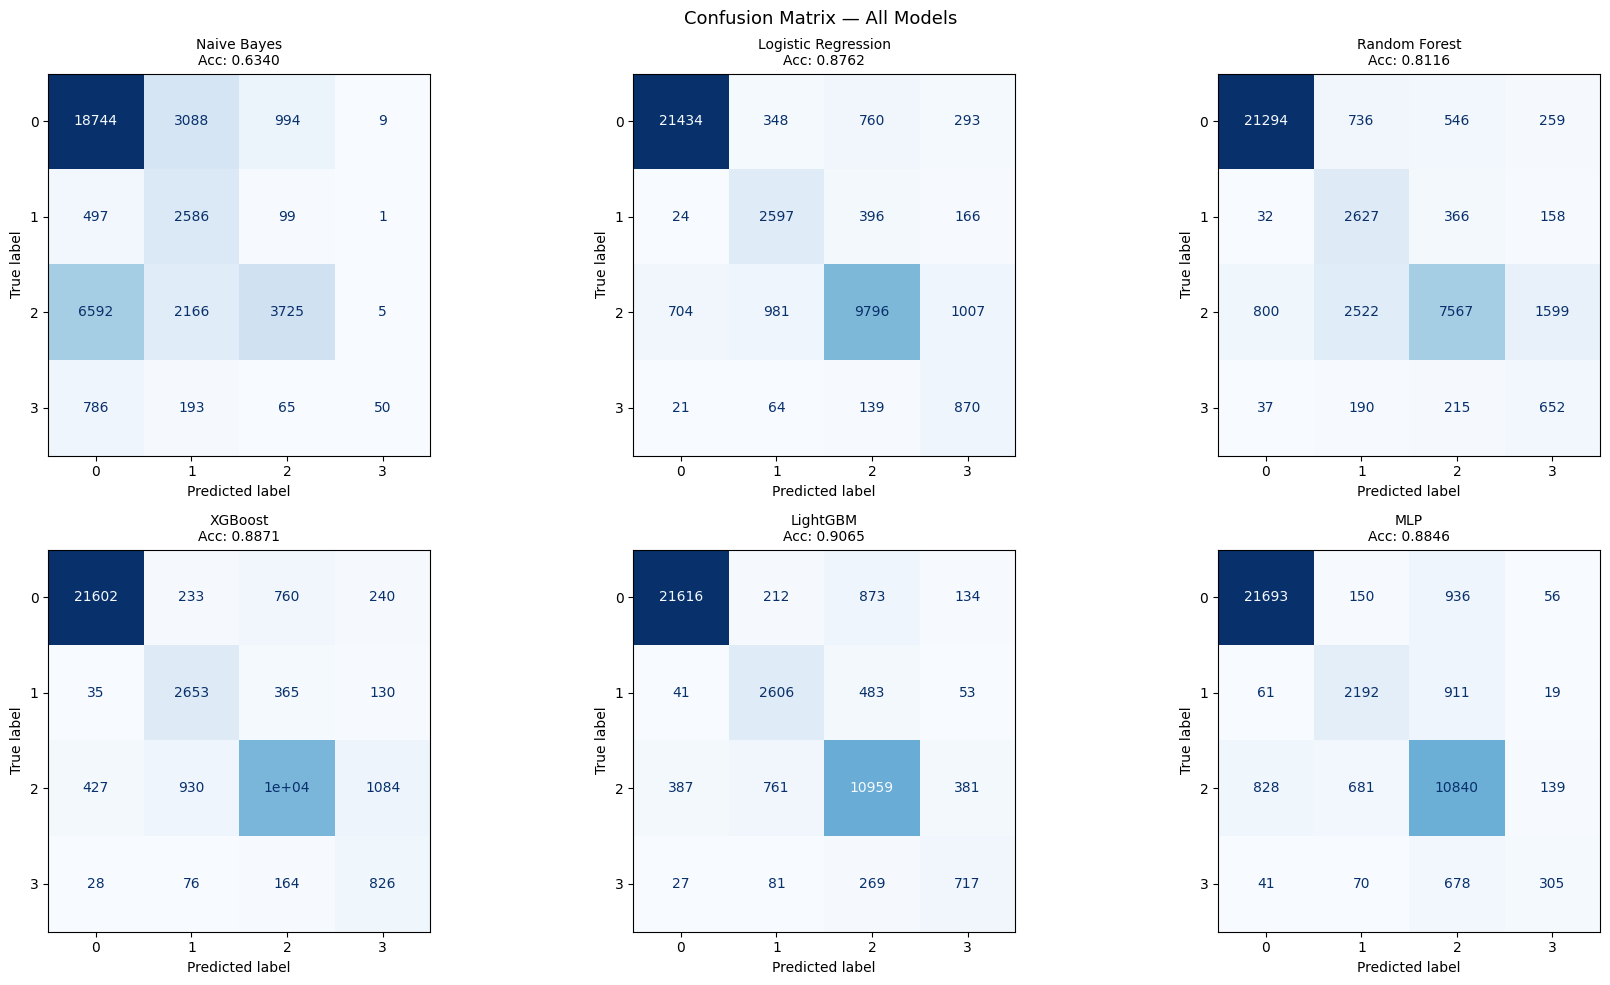

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() #convert 2d array in 1d array

plot_models = {
    'Naive Bayes'         : nb_val_pred,
    'Logistic Regression' : lr_val_pred,
    'Random Forest'       : rf_val_pred,
    'XGBoost'             : xgb_val_pred,
    'LightGBM'            : lgb_val_pred,
    'MLP'                 : mlp_val_pred,
}
for ax, (name, pred) in zip(axes, plot_models.items()): #zip axes and model iterate parally
    cm   = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1, 2, 3])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_val, pred):.4f}', fontsize=10)
plt.suptitle('Confusion Matrix — All Models', fontsize=13)
plt.tight_layout()
plt.show()

Generate Submission

In [37]:
# Step 1 — Get test probabilities
lr_proba  = lr_grid.best_estimator_.predict_proba(X_test)
lgb_proba = lgb_model.predict_proba(X_test)

# Step 2 — Apply best combo directly
test_preds = np.argmax(
    (0.6*lgb_proba + 0.4*lr_proba), axis=1
)
submission = pd.DataFrame({
    'ID'   : range(1, len(test_preds) + 1),
    'label': test_preds
})
submission.to_csv('submission.csv', index=False)

print("submission.csv saved!")
print(f"Shape : {submission.shape}")
print(f"\nPredicted label distribution:")
print(submission['label'].value_counts().sort_index())
print("\nSample:")
print(submission.head())

submission.csv saved!
Shape : (102000, 2)

Predicted label distribution:
label
0    56929
1     8999
2    32939
3     3133
Name: count, dtype: int64

Sample:
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2
